# S8 — Aprendizado de política e simulação de ROI

Esta seção é pós-confirmatória e exploratória. Ela traduz rankings de uplift em decisões de contato sob orçamento e simula cenários econômicos. A conclusão confirmatória permanece exclusivamente em S6: UpliftTree foi pré-selecionado, mas não mostrou vantagem confirmatória sobre o baseline de propensão (Delta Qini = -0,0088; IC95% [-0,0492, +0,0302]).

O ajuste usa somente `train_df`; a avaliação de política usa somente `val_df`. Nenhuma linha da partição confirmatória é aberta ou reutilizada. UpliftTree é o primário histórico; X+Tree é comparador exploratório. O melhor ponto observado na validação é descritivo e não constitui recomendação confirmatória.


## Índice

- [1. Dados e fronteira de desenvolvimento](#s8-1)
- [2. Políticas binárias](#s8-2)
- [3. Economia ilustrativa](#s8-3)
- [4. Extensão exploratória de três braços](#s8-4)
- [5. Leitura responsável](#s8-5)

---

In [1]:
from pathlib import Path
import logging
import os
import sys
logging.getLogger("duecredit").setLevel(logging.CRITICAL)
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = next(parent for parent in PROJECT_ROOT.parents if (parent / "src").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROJECT_ROOT as CONFIG_PROJECT_ROOT, SEED
from src.data import add_pooled_treatment, load_hillstrom
from src.i18n import make_lang
from src.policy_reports import (
    build_s8_policy_report, display_s8_policy_report, plot_s8_policy_report,
    save_s8_policy_artifacts,
)
from src.splits import get_train_val

PROJECT_ROOT = CONFIG_PROJECT_ROOT
ARTIFACTS_S8_DIR = PROJECT_ROOT / "artifacts" / "s8"
lang = make_lang('pt')
df = load_hillstrom()
train_df, val_df = get_train_val(add_pooled_treatment(df))


<a id="s8-1"></a>

## 1. Dados e fronteira de desenvolvimento

A propensão do tratamento pooled é conhecida como `2/3`, e a extensão de três braços tem probabilidade teórica `1/3` por braço. Os scores são ajustados no treino e congelados antes da avaliação na validação. A curva inteira é o resultado; qualquer máximo é apenas uma descrição deste split.


<a id="s8-2"></a>

## 2. Políticas binárias

Comparamos não tratar ninguém, tratar todos, alocação aleatória, targeting por propensão, UpliftTree e X+Tree. A política `treat_all` é um benchmark incondicional: abaixo de 100% ela excede deliberadamente o limite de contato e aparece marcada como não factível. As demais políticas respeitam o orçamento por seleção determinística dos maiores scores, com desempate pelo índice original.

A avaliação IPW cobre `visit` (primário), `conversion` (raro) e `spend` (base econômica). O bootstrap é pareado e estratificado pelos três braços observados; scores e máscaras ficam congelados em cada réplica.


<a id="s8-3"></a>

## 3. Economia ilustrativa

O dataset não contém custo de e-mail nem margem bruta. O spend observado é tratado somente como proxy de receita incremental. A receita incremental é então multiplicada por uma margem bruta hipotética para obter o lucro bruto. A grade de margens e custos é ilustrativa e não representa premissas da empresa. O custo de equilíbrio é margem vezes spend incremental por cliente, dividido pela taxa de contato.


<a id="s8-4"></a>

## 4. Extensão exploratória de três braços

A política escolhe entre No E-Mail, Mens E-Mail e Womens E-Mail pelo maior ganho líquido previsto. O ganho líquido é `margem × (spend previsto do e-mail − spend previsto do controle) − custo do e-mail`. Assim, No E-Mail permanece elegível quando os dois ganhos líquidos são não positivos. Os comparadores `all_mens` e `all_womens` são literais e não são confundidos com targeting; abaixo de 100% são benchmarks não factíveis.

As regras da árvore são um surrogate descritivo da ação recomendada pelo modelo. Elas medem fidelidade à política, não efeito causal individual.


treino=38,400 | validação=12,800
Modelos ajustados em train_df; políticas avaliadas em val_df.
Valor IPW de visit e delta vs. propensão nos budgets representativos
     policy  budget  incremental_value  delta_vs_propensity  ci_low  ci_high  budget_feasible
 no_contact     0.1             0.0000              -0.0094  0.0000   0.0000             True
 propensity     0.1             0.0094               0.0000  0.0039   0.0151             True
     random     0.1             0.0068              -0.0026  0.0030   0.0116             True
  treat_all     0.1             0.0609               0.0516  0.0470   0.0728            False
uplift_tree     0.1             0.0071              -0.0022  0.0035   0.0109             True
     x_tree     0.1             0.0151               0.0057  0.0110   0.0195             True
 no_contact     0.3             0.0000              -0.0263  0.0000   0.0000             True
 propensity     0.3             0.0263               0.0000  0.0173   0.0347        

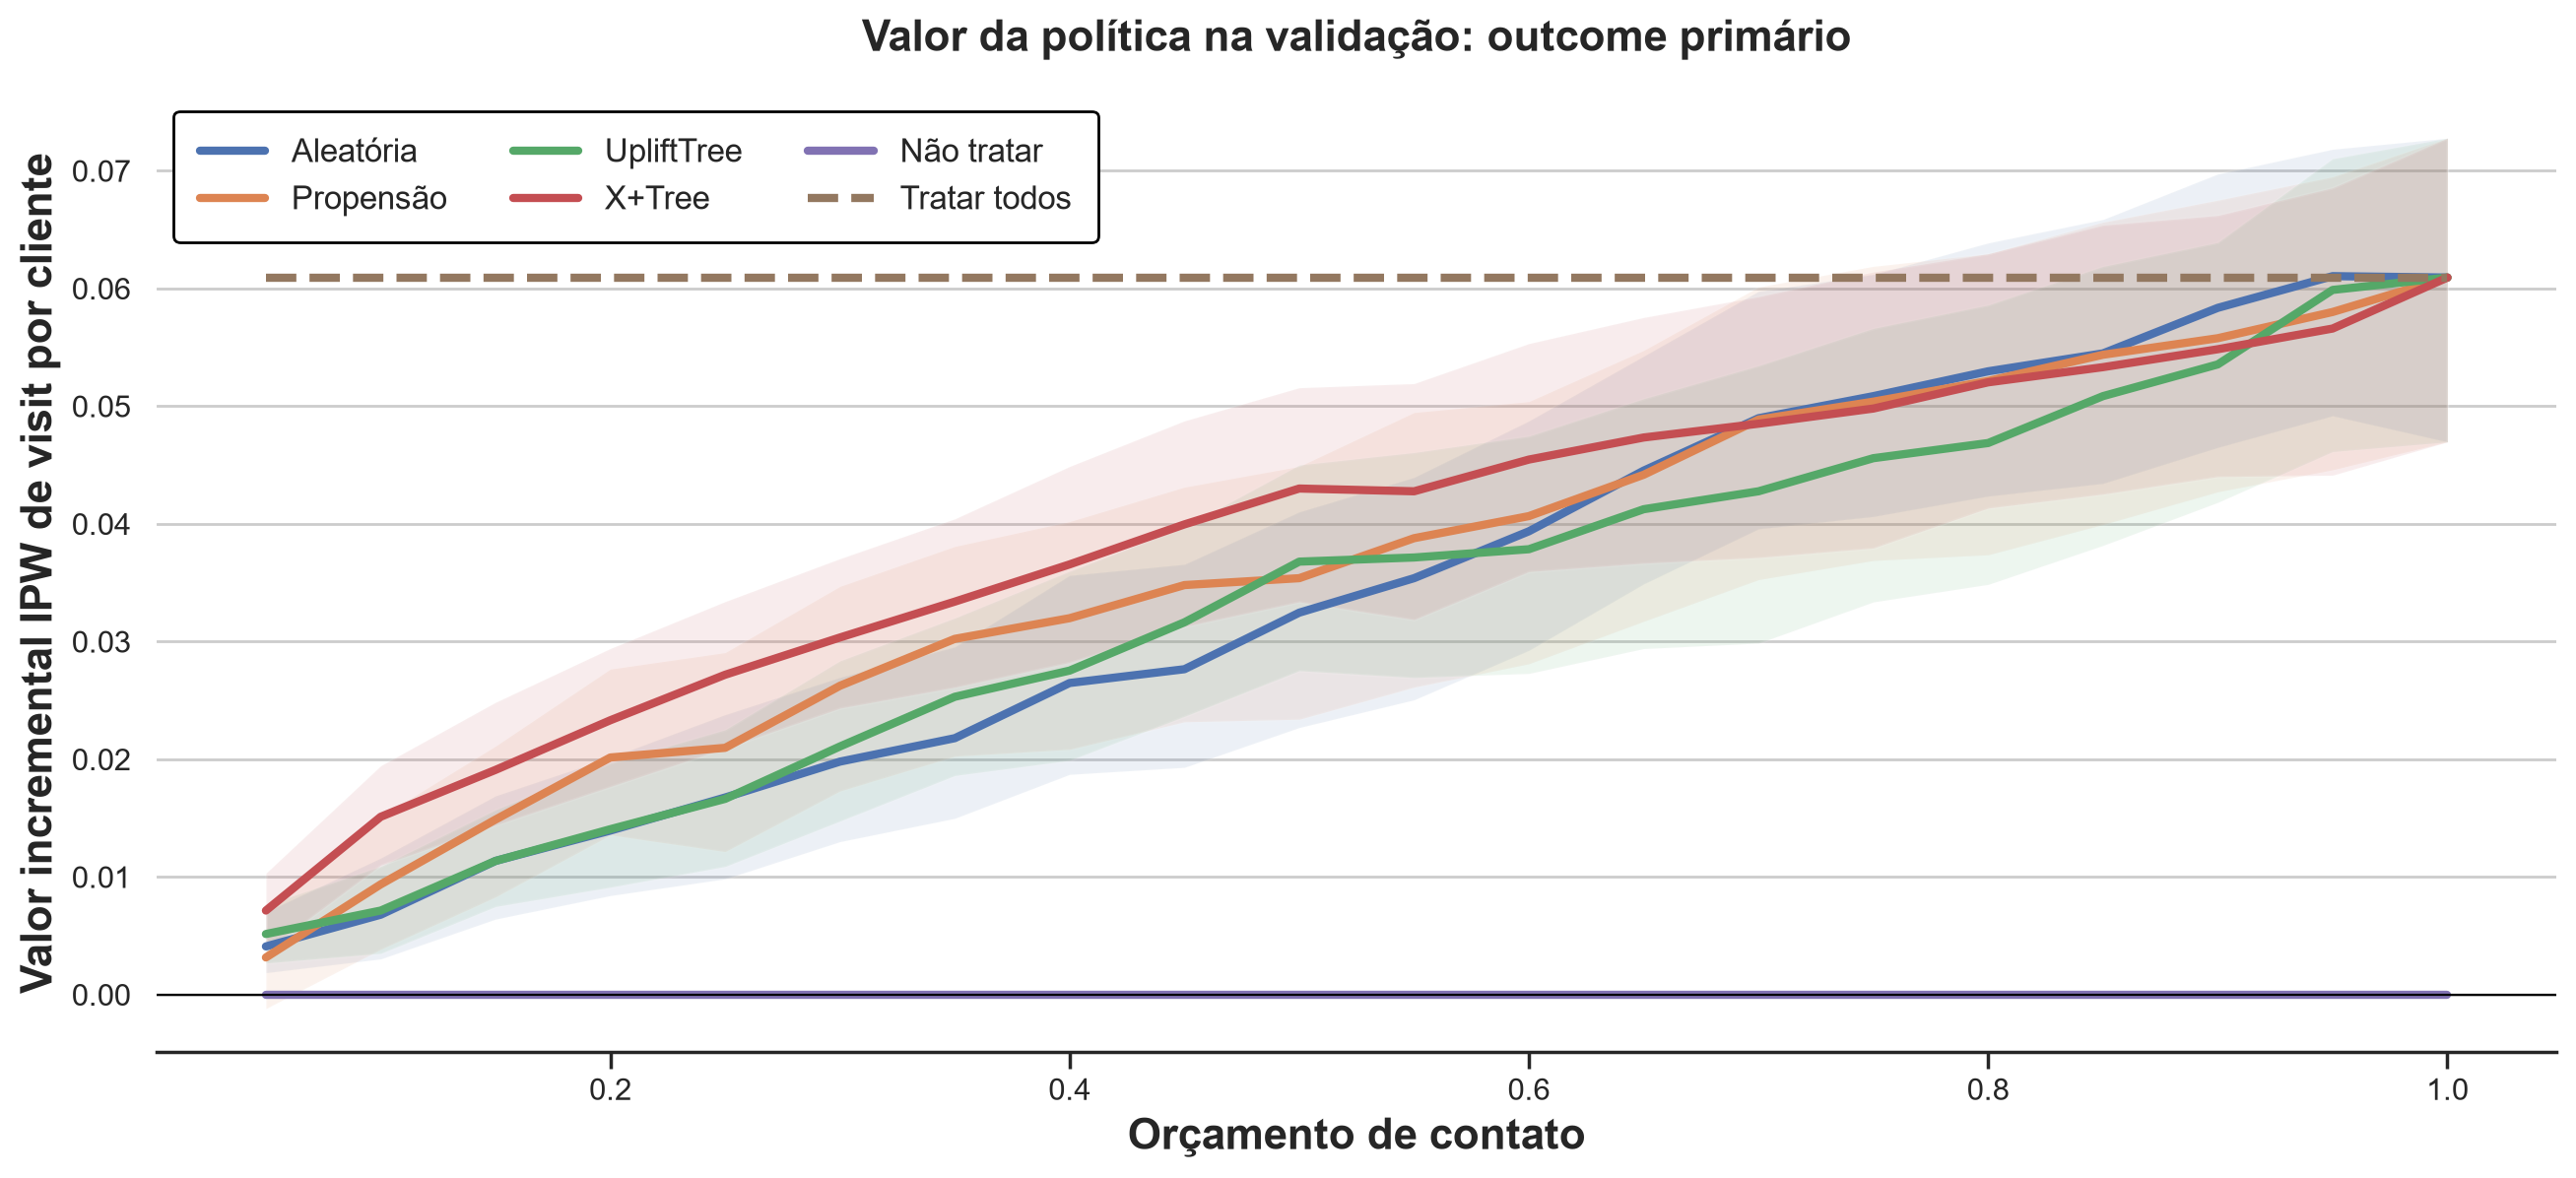

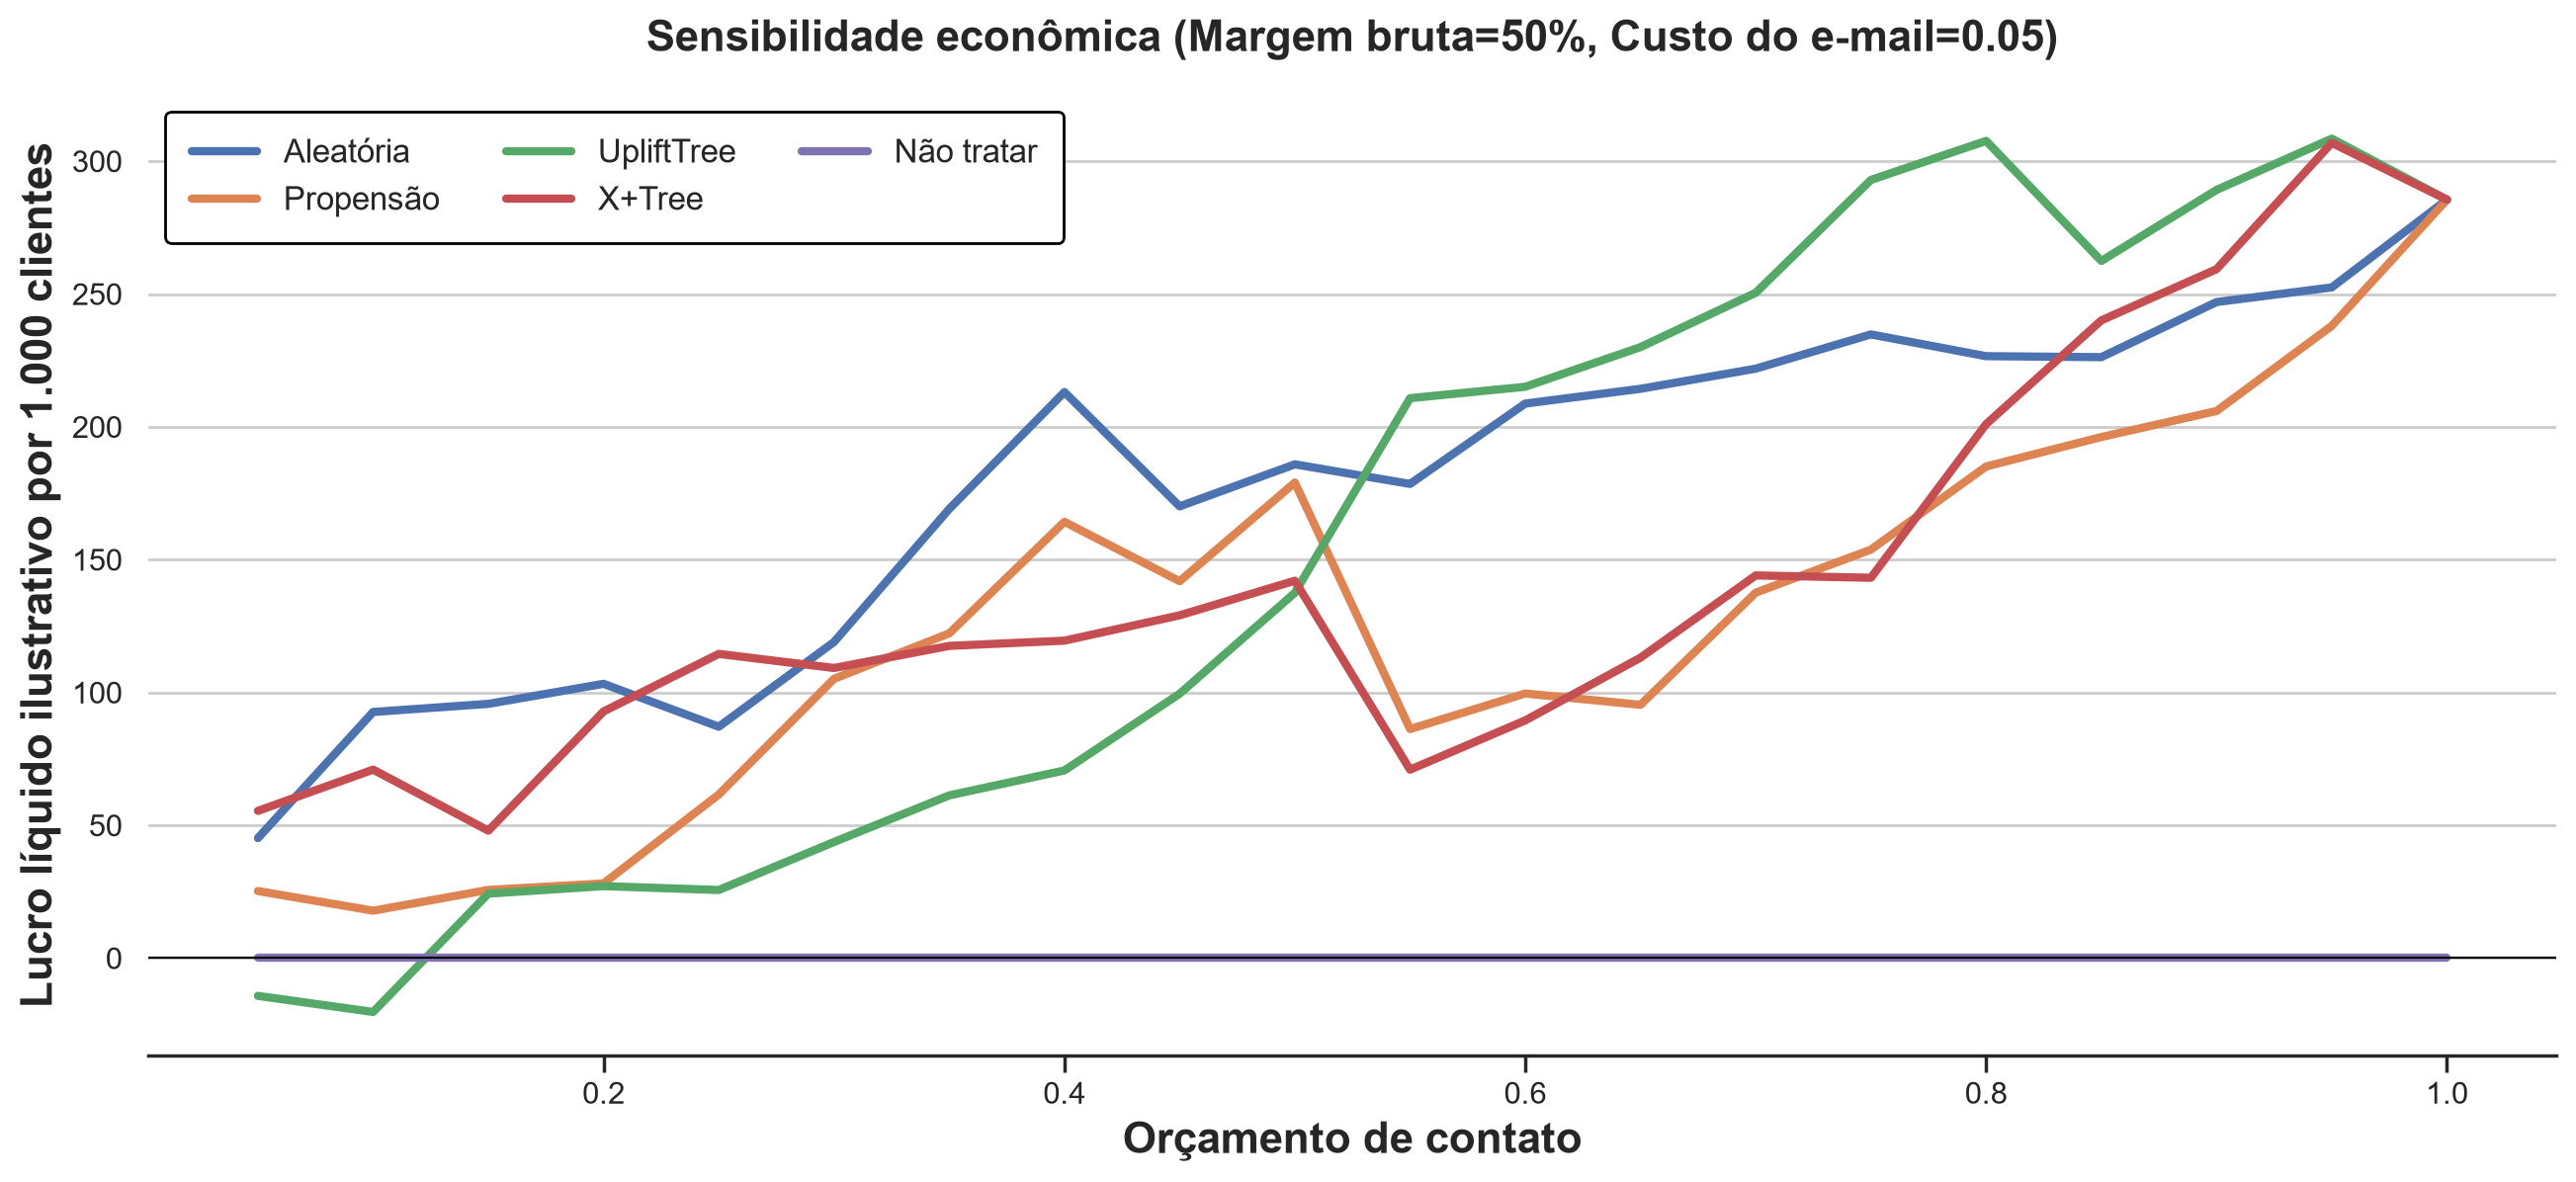

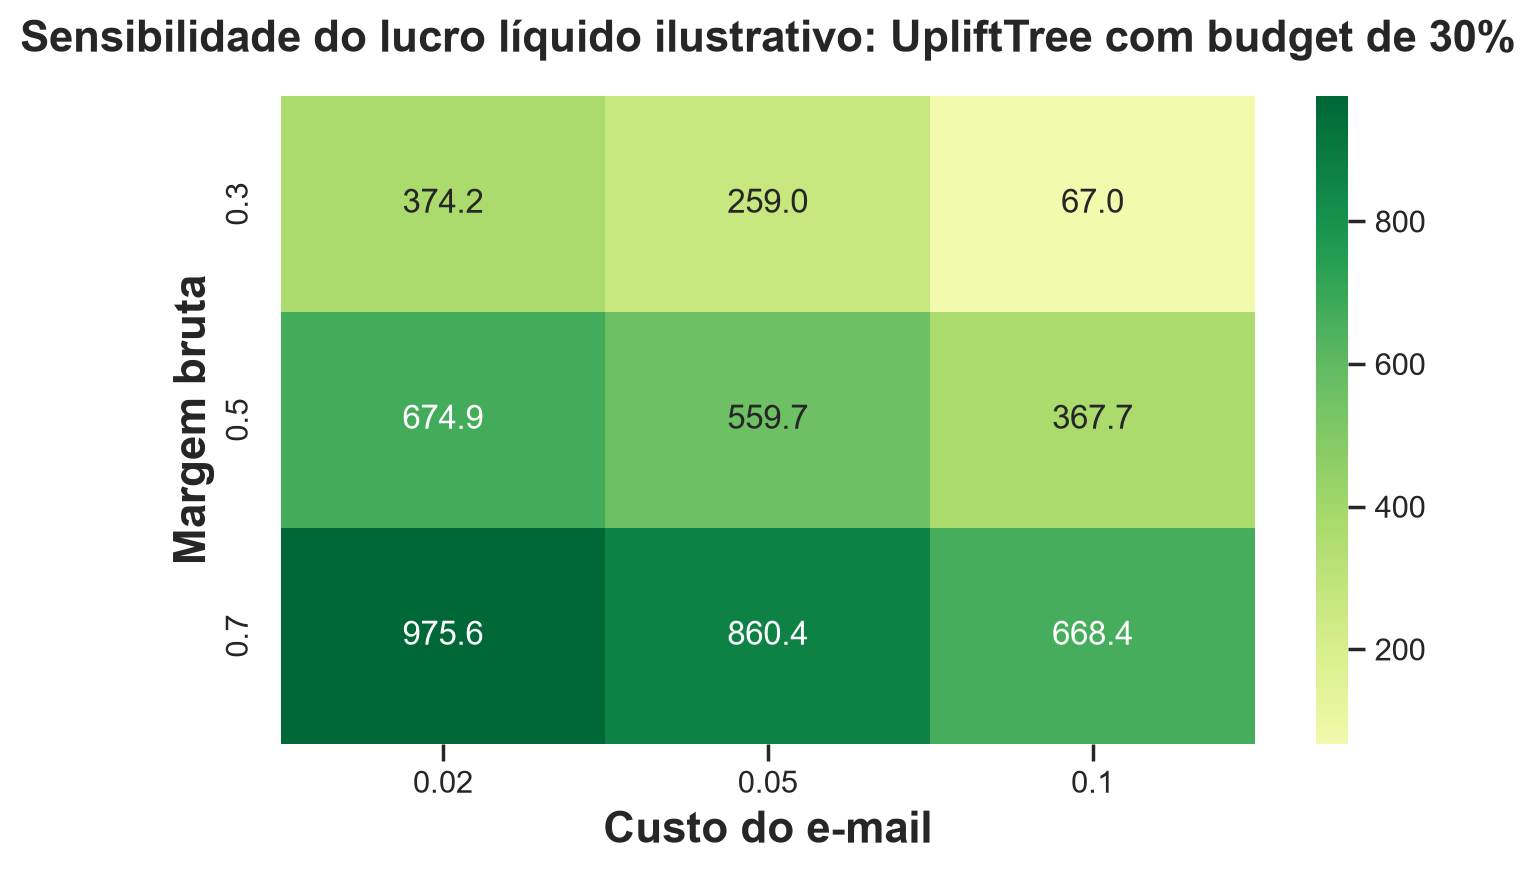

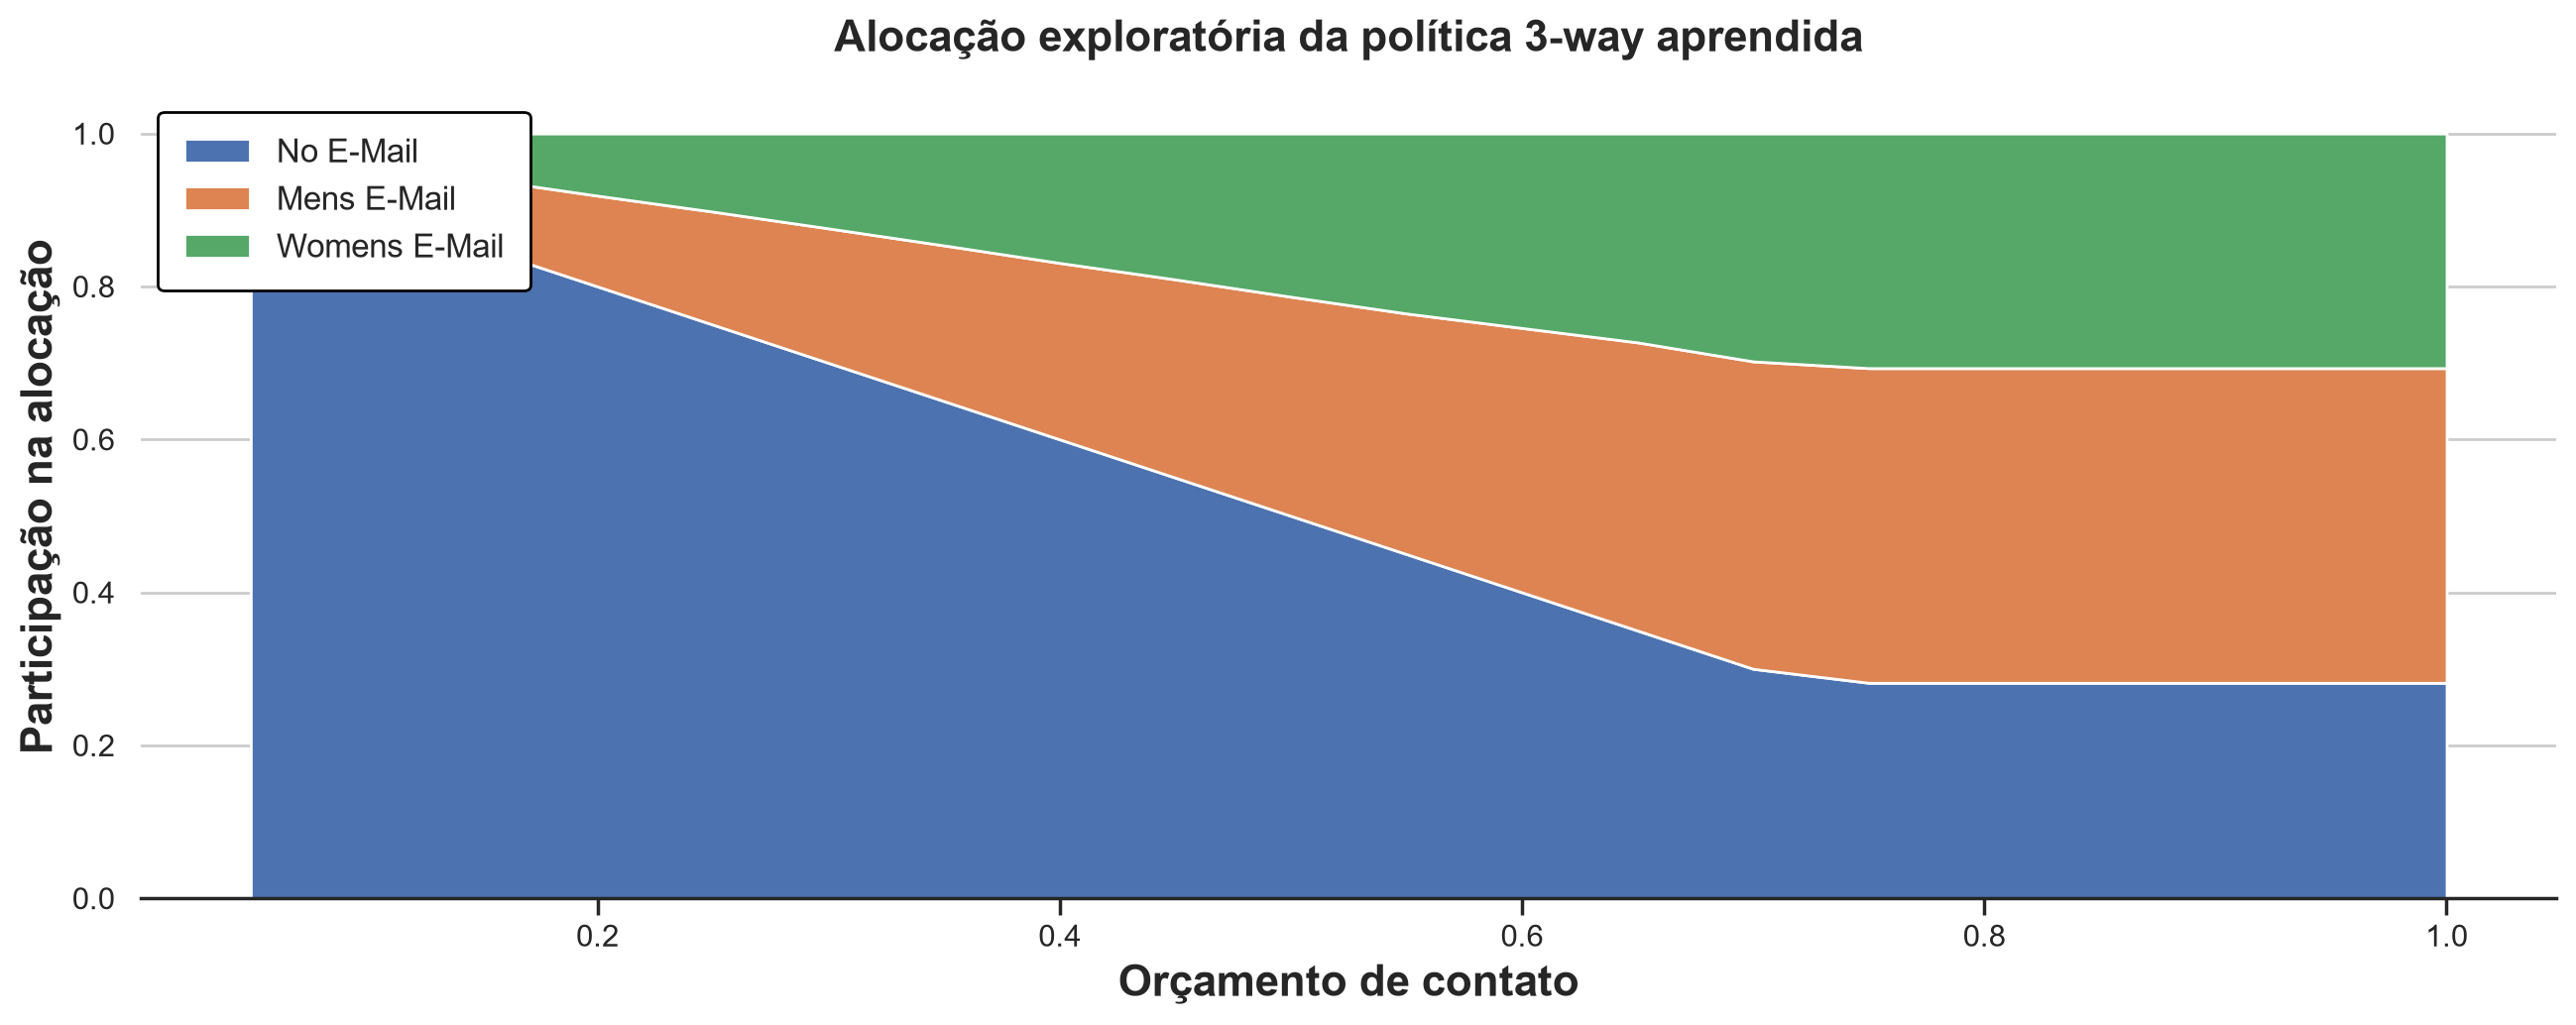

[<Figure size 1400x600 with 1 Axes>,
 <Figure size 1400x600 with 1 Axes>,
 <Figure size 700x400 with 2 Axes>,
 <Figure size 1400x500 with 1 Axes>]

In [2]:
report = build_s8_policy_report(train_df, val_df, seed=SEED)
save_s8_policy_artifacts(report, ARTIFACTS_S8_DIR)
display_s8_policy_report(report, lang=lang, artifacts_dir=ARTIFACTS_S8_DIR)
plot_s8_policy_report(report, lang=lang)


<a id="s8-5"></a>

## 5. Leitura responsável

Os artefatos permitem comparar valor incremental, incerteza e sensibilidade econômica ao longo de toda a grade de orçamento. Eles não alteram S6, não transformam um resultado de validação em evidência confirmatória e não autorizam declarar que uplift venceu o targeting por propensão.
